In [1]:
import pymysql
import os
import pandas as pd
import datetime as dt
import pytz
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import entropy


pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

In [2]:
#Connection to  MySQL server, parameters must be filled with correct information otherwise it won't work
conn = pymysql.connect(
    host = '127.0.0.1',
    user = 'root',
    password =  os.getenv("PASSWORD_MY_SQL"),
    database = 'data'
    )
cursor = conn.cursor()

# Preparing all addresses

In [3]:
#Extracting addresses with assigned timezone
sql = """SELECT eh.entity, eh.address, sd.timezone, sd.offsset FROM entities_heur as eh
    LEFT JOIN scraped_data as sd ON eh.entity = sd.entity
    LEFT JOIN exchanges_detection as ed on sd.id = ed.id
    WHERE sd.address is not null 
        and sd.location is not null 
        and sd.num_txs > 0 
        and sd.timezone is not null 
        and ed.arkham_entity is null 
        and (ed.arkham_label is null or ed.arkham_label = "Miner");"""
cursor.execute(sql)
data = cursor.fetchall()
len(data)

130214

In [4]:
data = pd.DataFrame(data, columns = ["entity", "address", "timezone", "offset"])
data.head()

,entity,address,timezone,offset
0,Entity 2436,121iyz8ZHtSNHX3mVTHzxztQ33cueBVEu5,Europe/Stockholm,1.0
1,Entity 2436,12418afg3GhCD56oHS5j9f2GzbcbP5oHjY,Europe/Stockholm,1.0
2,Entity 2436,12BmH6NTySEgudTSCYUbPtbn3tLtYyeWYg,Europe/Stockholm,1.0
3,Entity 2436,12DwYSkSw5H6twHcvGDu2tu3ZakdTFShB2,Europe/Stockholm,1.0
4,Entity 2436,12GmdvZKwPpdfRumDakRgJg2rcUG9T3inQ,Europe/Stockholm,1.0


In [5]:
data = data[~data["offset"].isna()]
len(data)

130214

In [6]:
#Transforming address to list and deleting duplicates
addresses = data["address"]
addresses = addresses.drop_duplicates()
addresses = addresses.tolist()

# Getting transaction data

In [7]:
#Getting all outgoing transaction to addresses from list
placeholders = ','.join(['%s'] * len(addresses))

query = f"""SELECT DISTINCT ti.txid, ti.input_order, ti.address, bd.mempool_entry_time, bd.fee, bd.num_inputs, bd.num_outputs, ti.value FROM tx_inputs AS ti
LEFT JOIN blockchain_data AS bd on ti.txid = bd.txid
WHERE address in ({placeholders});"""

cursor.execute(query, addresses)
database = cursor.fetchall()
database = pd.DataFrame(database, columns = ["txid", "input_order", "address", "mempool_entry_time", "fee", "num_inputs", "num_outputs", "value"])
database.head()

,txid,input_order,address,mempool_entry_time,fee,num_inputs,num_outputs,value
0,000049902d3f26ea6de81a0ea6416e5798934339edba0f45873da2ff39f01816,0,14aqB7KYWTWBwJht7zCFVifJCuV9bww1i8,2020-09-06 03:41:07,5.078947,1,1,0.108605
1,00004ca51f952c2f308dc85ddff72cf33e50b1f280cb7af20fccf69d5e857091,0,1R8wSZR6YCDDSDc1m1qSHHh5X5GUab9XX,2014-12-20 15:31:40,22.831050,2,2,0.002373
2,00004ca51f952c2f308dc85ddff72cf33e50b1f280cb7af20fccf69d5e857091,1,18rnnk2vr58dV9dHsxMFbRhyZ8NVFBNo2o,2014-12-20 15:31:40,22.831050,2,2,0.999900
3,00006d4fee0006f2f51b4e6cde3197d9899ec53fafdc98a0ae610ba794ae442c,0,1L56rn8BDX68iZfEJftFGJJHYDN3Gv1UL7,2015-11-26 13:20:49,26.737968,2,2,0.298024
4,00006d4fee0006f2f51b4e6cde3197d9899ec53fafdc98a0ae610ba794ae442c,1,1L56rn8BDX68iZfEJftFGJJHYDN3Gv1UL7,2015-11-26 13:20:49,26.737968,2,2,0.158314


In [8]:
#Merging transaction data to addresses to obtain entity identification number
db_final = database.merge(
    data,
    how = "left",
    on = "address"
)
db_final.head()

,txid,input_order,address,mempool_entry_time,fee,num_inputs,num_outputs,value,entity,timezone,offset
0,000049902d3f26ea6de81a0ea6416e5798934339edba0f45873da2ff39f01816,0,14aqB7KYWTWBwJht7zCFVifJCuV9bww1i8,2020-09-06 03:41:07,5.078947,1,1,0.108605,Entity 1861,Europe/Copenhagen,1.0
1,00004ca51f952c2f308dc85ddff72cf33e50b1f280cb7af20fccf69d5e857091,0,1R8wSZR6YCDDSDc1m1qSHHh5X5GUab9XX,2014-12-20 15:31:40,22.831050,2,2,0.002373,Entity 1940,Europe/Kyiv,2.0
2,00004ca51f952c2f308dc85ddff72cf33e50b1f280cb7af20fccf69d5e857091,0,1R8wSZR6YCDDSDc1m1qSHHh5X5GUab9XX,2014-12-20 15:31:40,22.831050,2,2,0.002373,Entity 472,Asia/Kolkata,5.5
3,00004ca51f952c2f308dc85ddff72cf33e50b1f280cb7af20fccf69d5e857091,0,1R8wSZR6YCDDSDc1m1qSHHh5X5GUab9XX,2014-12-20 15:31:40,22.831050,2,2,0.002373,Entity 2162,Africa/Johannesburg,2.0
4,00004ca51f952c2f308dc85ddff72cf33e50b1f280cb7af20fccf69d5e857091,0,1R8wSZR6YCDDSDc1m1qSHHh5X5GUab9XX,2014-12-20 15:31:40,22.831050,2,2,0.002373,Entity 504,Asia/Kuching,8.0


In [9]:
#Creating help variable with adjusted time to UTC +0:00
db_final["time_adjusted"] = db_final.apply(
    lambda r: r["mempool_entry_time"] + pd.Timedelta(hours = r["offset"]),
    axis = 1
)
db_final = db_final.drop_duplicates(subset = ["txid"])
db_final.head()

/tmp/ipykernel_7319/37489651.py:3: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  lambda r: r["mempool_entry_time"] + pd.Timedelta(hours = r["offset"]),


,txid,input_order,address,mempool_entry_time,fee,num_inputs,num_outputs,value,entity,timezone,offset,time_adjusted
0,000049902d3f26ea6de81a0ea6416e5798934339edba0f45873da2ff39f01816,0,14aqB7KYWTWBwJht7zCFVifJCuV9bww1i8,2020-09-06 03:41:07,5.078947,1,1,0.108605,Entity 1861,Europe/Copenhagen,1.0,2020-09-06 04:41:07
1,00004ca51f952c2f308dc85ddff72cf33e50b1f280cb7af20fccf69d5e857091,0,1R8wSZR6YCDDSDc1m1qSHHh5X5GUab9XX,2014-12-20 15:31:40,22.831050,2,2,0.002373,Entity 1940,Europe/Kyiv,2.0,2014-12-20 17:31:40
11,00006d4fee0006f2f51b4e6cde3197d9899ec53fafdc98a0ae610ba794ae442c,0,1L56rn8BDX68iZfEJftFGJJHYDN3Gv1UL7,2015-11-26 13:20:49,26.737968,2,2,0.298024,Entity 505,Asia/Manila,8.0,2015-11-26 21:20:49
13,00007bf94d53e5a2cfb4d7aa94039553fadd80f85b9b5eca57de2bd986d56e2e,0,188FPxXv1i4d9F7jQUYUf1Zt2RTh7RnFCG,2016-05-15 20:19:07,34.793774,1,2,0.285407,Entity 70,Europe/Kyiv,2.0,2016-05-15 22:19:07
14,0000a1407c1f573268ea82a20305ed68294351a1f665d08544c3900987df3c43,0,1NissionTGS4S8DvNmGf13amLQuWUZM1nd,2017-08-17 00:59:42,389.105058,1,2,0.107424,Entity 2090,Asia/Tokyo,9.0,2017-08-17 09:59:42


In [10]:
len(db_final)

324521

In [11]:
db_final[db_final["mempool_entry_time"] >= "2022-02-27 21:09:19"].head()

,txid,input_order,address,mempool_entry_time,fee,num_inputs,num_outputs,value,entity,timezone,offset,time_adjusted
128,000dfdb43f35a86eebf5049d4a3619b983170bff4939e3fc34e2f1d40b15b509,0,bc1p8pxnpc8vpgzttxg8eqz3c6dsde5w5pghpwqql47swtwfqtcray0qxnp0ru,2026-06-26 02:27:05,3.228365,3,3,0.028409,Entity 2057,Europe/London,0.0,2026-06-26 02:27:05
204,00164d4ee62e431220e1896b0c10a878980a385282040634bb8e97a34c702af4,0,1ALEX2m6HHHrZQa5WV7xgDSMDMFs2m2SWX,2023-03-09 07:45:39,11.417323,1,2,0.854423,Entity 7692,America/Toronto,-5.0,2023-03-09 02:45:39
250,00199e8085e1d4a3349f2fafc60dbab9cd34b48e62f080eb6e88849b6918dba5,0,1GxAQsMTJf79Pxy7n3LTfZTDoJnhSYJ2FX,2023-11-02 00:39:02,10.055118,1,2,0.011367,Entity 4766,Australia/Melbourne,11.0,2023-11-02 11:39:02
331,001caadfc549493dc4a88541940627a711da930b53607b6473612299d76d15b7,0,15X6dXyBBhEAUnzzuSKbRjCVhXG5jGpRSv,2022-03-31 15:14:19,9.696237,2,2,0.046754,Entity 661,Europe/Moscow,3.0,2022-03-31 18:14:19
482,002247ed71040442bcdf7d1f88c8d6266073f4accfd63ca0ad70bd8f9817882c,0,bc1qtuy8xfnap6l92288zmvgdmea2qmcm8x4v3cqek,2026-07-19 18:20:13,3.406475,1,3,0.010939,Entity 2057,Europe/London,0.0,2026-07-19 18:20:13


In [12]:
len(db_final[db_final["mempool_entry_time"] >= "2022-02-27 21:09:19"])

12723

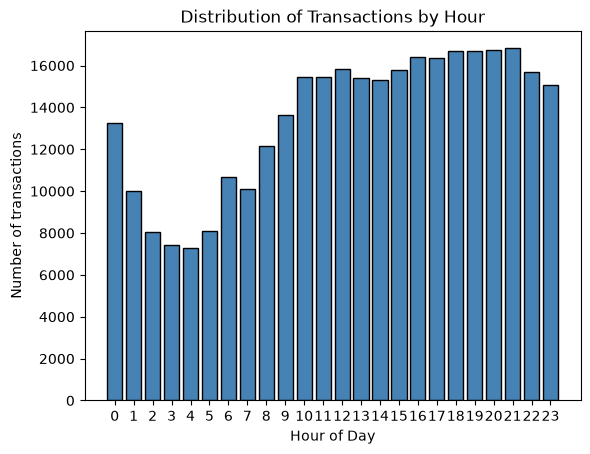

In [13]:
#General  graph of transaction activity tranformed to UTC +0:00
counts, bins, patches = plt.hist(db_final["time_adjusted"].dt.hour, bins=np.arange(25), 
                                 rwidth=0.8, color='steelblue', edgecolor='black')

plt.xticks(np.arange(24) + 0.5, labels=range(24))

plt.title("Distribution of Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of transactions")

plt.show()

# Creating aggregated dataset with relative values 

In [14]:
#Extracting only hour of transaction from dataset
db_final["hour"] = pd.to_datetime(db_final["mempool_entry_time"]).dt.hour

In [15]:
#Aggregation of transaction into entities
pivot = (
    db_final.pivot_table(
        index=["entity", "offset"],
        columns="hour",
        values="txid",
        aggfunc="count",
        fill_value=0
    )
)

In [16]:
pivot.head()

,hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
entity,offset,,,,,,,,,,,,,,,,,,,,,,,,
Entity 100,7.0,4,8,5,11,11,13,7,12,11,10,10,16,8,7,12,12,14,26,8,3,2,3,0,2
Entity 1000,2.0,5,5,3,1,0,1,2,0,1,1,4,1,2,2,0,0,0,1,0,1,0,1,0,1
Entity 1001,2.0,1,1,2,2,3,3,5,9,2,1,1,1,0,2,0,0,0,1,0,0,0,0,0,0
Entity 1002,-5.0,2,3,0,0,0,0,0,0,0,0,0,0,1,1,2,3,6,1,2,0,3,2,1,5
Entity 1003,7.0,0,0,1,1,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [17]:
table = pivot.reset_index()
table.columns.name = None
table.head()

,entity,offset,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
0,Entity 100,7.0,4,8,5,11,11,13,7,12,11,10,10,16,8,7,12,12,14,26,8,3,2,3,0,2
1,Entity 1000,2.0,5,5,3,1,0,1,2,0,1,1,4,1,2,2,0,0,0,1,0,1,0,1,0,1
2,Entity 1001,2.0,1,1,2,2,3,3,5,9,2,1,1,1,0,2,0,0,0,1,0,0,0,0,0,0
3,Entity 1002,-5.0,2,3,0,0,0,0,0,0,0,0,0,0,1,1,2,3,6,1,2,0,3,2,1,5
4,Entity 1003,7.0,0,0,1,1,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [18]:
cols_to_sum = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
table["total"] = table[cols_to_sum].sum(axis = 1)
table["log_total"] = table["total"].apply(lambda r: np.log(r))

#Bayesian normalization of data 
alpha = 1
table[cols_to_sum] = (table[cols_to_sum] + alpha).div(table["total"] + 24*alpha, axis = 0)

In [19]:
#Finding the middle of the 5 hour minimum inactivity window and the % value of this window
hourly_data = table[cols_to_sum]
circular_data = pd.concat([hourly_data, hourly_data.iloc[:,:4]], axis = 1)
rolling_sums = circular_data.T.rolling(window=5).sum().T
hours = (rolling_sums.iloc[:, 4:].idxmin(axis=1).astype(int) - 2)%24
table["min_5h_activity"] = hours
table["min_5h_activity_sin"] = np.sin(hours*np.pi/12)
table["min_5h_activity_cos"] = np.cos(hours*np.pi/12)
table["min_5h_activity_%"] = rolling_sums.iloc[:, 4:].min(axis=1)



In [20]:
#Adding lifespan of entity in days
lifespan_df = db_final.groupby('entity').agg(
    first_tx=('mempool_entry_time', 'min'),
    last_tx=('mempool_entry_time', 'max')
).reset_index()
lifespan_df['lifespan_days'] = (lifespan_df['last_tx'] - lifespan_df['first_tx']).dt.total_seconds() / 86400
table = table.merge(lifespan_df[["entity", "lifespan_days"]], how = "left", on = "entity")

In [21]:
#Adding week days and weekend activity
db_final["day_type"] = np.where(db_final["mempool_entry_time"].dt.dayofweek < 5, "weekday", "weekend")
db_final.head()

,txid,input_order,address,mempool_entry_time,fee,num_inputs,num_outputs,value,entity,timezone,offset,time_adjusted,hour,day_type
0,000049902d3f26ea6de81a0ea6416e5798934339edba0f45873da2ff39f01816,0,14aqB7KYWTWBwJht7zCFVifJCuV9bww1i8,2020-09-06 03:41:07,5.078947,1,1,0.108605,Entity 1861,Europe/Copenhagen,1.0,2020-09-06 04:41:07,3,weekend
1,00004ca51f952c2f308dc85ddff72cf33e50b1f280cb7af20fccf69d5e857091,0,1R8wSZR6YCDDSDc1m1qSHHh5X5GUab9XX,2014-12-20 15:31:40,22.831050,2,2,0.002373,Entity 1940,Europe/Kyiv,2.0,2014-12-20 17:31:40,15,weekend
11,00006d4fee0006f2f51b4e6cde3197d9899ec53fafdc98a0ae610ba794ae442c,0,1L56rn8BDX68iZfEJftFGJJHYDN3Gv1UL7,2015-11-26 13:20:49,26.737968,2,2,0.298024,Entity 505,Asia/Manila,8.0,2015-11-26 21:20:49,13,weekday
13,00007bf94d53e5a2cfb4d7aa94039553fadd80f85b9b5eca57de2bd986d56e2e,0,188FPxXv1i4d9F7jQUYUf1Zt2RTh7RnFCG,2016-05-15 20:19:07,34.793774,1,2,0.285407,Entity 70,Europe/Kyiv,2.0,2016-05-15 22:19:07,20,weekend
14,0000a1407c1f573268ea82a20305ed68294351a1f665d08544c3900987df3c43,0,1NissionTGS4S8DvNmGf13amLQuWUZM1nd,2017-08-17 00:59:42,389.105058,1,2,0.107424,Entity 2090,Asia/Tokyo,9.0,2017-08-17 09:59:42,0,weekday


In [22]:
table_weekday_weekend = (
    db_final.pivot_table(
        index=["entity", "offset", "day_type"],
        columns="hour",
        values="txid",
        aggfunc="count",
        fill_value=0
    )
)
table_weekday_weekend = table_weekday_weekend.reset_index()

cols_to_sum = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
table_weekday_weekend["total"] = table_weekday_weekend[cols_to_sum].sum(axis = 1)
table_weekday_weekend["log_total"] = table_weekday_weekend["total"].apply(lambda r: np.log(r))

#Bayesian normalization of data 
alpha = 1
table_weekday_weekend[cols_to_sum] = (table_weekday_weekend[cols_to_sum] + alpha).div(table_weekday_weekend["total"] + 24*alpha, axis = 0)

df_unstacked = table_weekday_weekend.set_index(['entity', 'offset', 'day_type']).unstack('day_type')
df_unstacked.columns = [f"{str(hour)}_{day}" for hour, day in df_unstacked.columns]
df_wide = df_unstacked.reset_index()
df_wide = df_wide.fillna(0)

In [23]:
table_weekday_weekend.head()

hour,entity,offset,day_type,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,total,log_total
0,Entity 100,7.0,weekday,0.022599,0.050847,0.028249,0.050847,0.067797,0.073446,0.039548,0.045198,0.033898,0.056497,0.050847,0.050847,0.028249,0.022599,0.056497,0.073446,0.084746,0.062147,0.033898,0.022599,0.011299,0.016949,0.005650,0.011299,153,5.030438
1,Entity 100,7.0,weekend,0.023256,0.011628,0.023256,0.046512,0.011628,0.023256,0.023256,0.069767,0.081395,0.023256,0.034884,0.104651,0.058140,0.058140,0.046512,0.011628,0.011628,0.197674,0.046512,0.011628,0.023256,0.023256,0.011628,0.023256,62,4.127134
2,Entity 1000,2.0,weekday,0.100000,0.100000,0.080000,0.040000,0.020000,0.020000,0.040000,0.020000,0.040000,0.040000,0.080000,0.040000,0.060000,0.040000,0.020000,0.020000,0.020000,0.040000,0.020000,0.040000,0.020000,0.040000,0.020000,0.040000,26,3.258097
3,Entity 1000,2.0,weekend,0.066667,0.066667,0.033333,0.033333,0.033333,0.066667,0.066667,0.033333,0.033333,0.033333,0.066667,0.033333,0.033333,0.066667,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,6,1.791759
4,Entity 1001,2.0,weekday,0.035714,0.035714,0.035714,0.053571,0.071429,0.071429,0.107143,0.178571,0.053571,0.035714,0.035714,0.035714,0.017857,0.053571,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,32,3.465736


In [24]:
df_wide.head()

,entity,offset,0_weekday,0_weekend,1_weekday,1_weekend,2_weekday,2_weekend,3_weekday,3_weekend,4_weekday,4_weekend,5_weekday,5_weekend,6_weekday,6_weekend,7_weekday,7_weekend,8_weekday,8_weekend,9_weekday,9_weekend,10_weekday,10_weekend,11_weekday,11_weekend,12_weekday,12_weekend,13_weekday,13_weekend,14_weekday,14_weekend,15_weekday,15_weekend,16_weekday,16_weekend,17_weekday,17_weekend,18_weekday,18_weekend,19_weekday,19_weekend,20_weekday,20_weekend,21_weekday,21_weekend,22_weekday,22_weekend,23_weekday,23_weekend,total_weekday,total_weekend,log_total_weekday,log_total_weekend
0,Entity 100,7.0,0.022599,0.023256,0.050847,0.011628,0.028249,0.023256,0.050847,0.046512,0.067797,0.011628,0.073446,0.023256,0.039548,0.023256,0.045198,0.069767,0.033898,0.081395,0.056497,0.023256,0.050847,0.034884,0.050847,0.104651,0.028249,0.058140,0.022599,0.058140,0.056497,0.046512,0.073446,0.011628,0.084746,0.011628,0.062147,0.197674,0.033898,0.046512,0.022599,0.011628,0.011299,0.023256,0.016949,0.023256,0.005650,0.011628,0.011299,0.023256,153.0,62.0,5.030438,4.127134
1,Entity 1000,2.0,0.100000,0.066667,0.100000,0.066667,0.080000,0.033333,0.040000,0.033333,0.020000,0.033333,0.020000,0.066667,0.040000,0.066667,0.020000,0.033333,0.040000,0.033333,0.040000,0.033333,0.080000,0.066667,0.040000,0.033333,0.060000,0.033333,0.040000,0.066667,0.020000,0.033333,0.020000,0.033333,0.020000,0.033333,0.040000,0.033333,0.020000,0.033333,0.040000,0.033333,0.020000,0.033333,0.040000,0.033333,0.020000,0.033333,0.040000,0.033333,26.0,6.0,3.258097,1.791759
2,Entity 1001,2.0,0.035714,0.038462,0.035714,0.038462,0.035714,0.076923,0.053571,0.038462,0.071429,0.038462,0.071429,0.038462,0.107143,0.038462,0.178571,0.038462,0.053571,0.038462,0.035714,0.038462,0.035714,0.038462,0.035714,0.038462,0.017857,0.038462,0.053571,0.038462,0.017857,0.038462,0.017857,0.038462,0.017857,0.038462,0.017857,0.076923,0.017857,0.038462,0.017857,0.038462,0.017857,0.038462,0.017857,0.038462,0.017857,0.038462,0.017857,0.038462,32.0,2.0,3.465736,0.693147
3,Entity 1002,-5.0,0.066667,0.028571,0.066667,0.057143,0.022222,0.028571,0.022222,0.028571,0.022222,0.028571,0.022222,0.028571,0.022222,0.028571,0.022222,0.028571,0.022222,0.028571,0.022222,0.028571,0.022222,0.028571,0.022222,0.028571,0.022222,0.057143,0.022222,0.057143,0.044444,0.057143,0.088889,0.028571,0.133333,0.057143,0.044444,0.028571,0.066667,0.028571,0.022222,0.028571,0.066667,0.057143,0.066667,0.028571,0.022222,0.057143,0.044444,0.142857,21.0,11.0,3.044522,2.397895
4,Entity 1003,7.0,0.034483,0.000000,0.034483,0.000000,0.068966,0.000000,0.068966,0.000000,0.034483,0.000000,0.034483,0.000000,0.137931,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,0.034483,0.000000,5.0,0.0,1.609438,0.000000


In [25]:
table = table.merge(df_wide[["entity", 
                             "0_weekday", "1_weekday", "2_weekday", "3_weekday", "4_weekday", "5_weekday", "6_weekday", "7_weekday", "8_weekday", "9_weekday", "10_weekday", "11_weekday", "12_weekday", "13_weekday", "14_weekday", "15_weekday", "16_weekday", "17_weekday", "18_weekday", "19_weekday", "20_weekday", "21_weekday", "22_weekday", "23_weekday",
                             "0_weekend", "1_weekend", "2_weekend", "3_weekend", "4_weekend", "5_weekend", "6_weekend", "7_weekend", "8_weekend", "9_weekend", "10_weekend", "11_weekend", "12_weekend", "13_weekend", "14_weekend", "15_weekend", "16_weekend", "17_weekend", "18_weekend", "19_weekend", "20_weekend", "21_weekend", "22_weekend", "23_weekend",
                             "total_weekday", "total_weekend"]], how = "left", on = "entity")

In [26]:
table.head()

,entity,offset,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,total,log_total,min_5h_activity,min_5h_activity_sin,min_5h_activity_cos,min_5h_activity_%,lifespan_days,0_weekday,1_weekday,2_weekday,3_weekday,4_weekday,5_weekday,6_weekday,7_weekday,8_weekday,9_weekday,10_weekday,11_weekday,12_weekday,13_weekday,14_weekday,15_weekday,16_weekday,17_weekday,18_weekday,19_weekday,20_weekday,21_weekday,22_weekday,23_weekday,0_weekend,1_weekend,2_weekend,3_weekend,4_weekend,5_weekend,6_weekend,7_weekend,8_weekend,9_weekend,10_weekend,11_weekend,12_weekend,13_weekend,14_weekend,15_weekend,16_weekend,17_weekend,18_weekend,19_weekend,20_weekend,21_weekend,22_weekend,23_weekend,total_weekday,total_weekend
0,Entity 100,7.0,0.020921,0.037657,0.025105,0.050209,0.050209,0.058577,0.033473,0.054393,0.050209,0.046025,0.046025,0.071130,0.037657,0.033473,0.054393,0.054393,0.062762,0.112971,0.037657,0.016736,0.012552,0.016736,0.004184,0.012552,215,5.370638,21,-0.707107,0.707107,0.062762,527.561829,0.022599,0.050847,0.028249,0.050847,0.067797,0.073446,0.039548,0.045198,0.033898,0.056497,0.050847,0.050847,0.028249,0.022599,0.056497,0.073446,0.084746,0.062147,0.033898,0.022599,0.011299,0.016949,0.005650,0.011299,0.023256,0.011628,0.023256,0.046512,0.011628,0.023256,0.023256,0.069767,0.081395,0.023256,0.034884,0.104651,0.058140,0.058140,0.046512,0.011628,0.011628,0.197674,0.046512,0.011628,0.023256,0.023256,0.011628,0.023256,153.0,62.0
1,Entity 1000,2.0,0.107143,0.107143,0.071429,0.035714,0.017857,0.035714,0.053571,0.017857,0.035714,0.035714,0.089286,0.035714,0.053571,0.053571,0.017857,0.017857,0.017857,0.035714,0.017857,0.035714,0.017857,0.035714,0.017857,0.035714,32,3.465736,16,-0.866025,-0.500000,0.107143,125.700324,0.100000,0.100000,0.080000,0.040000,0.020000,0.020000,0.040000,0.020000,0.040000,0.040000,0.080000,0.040000,0.060000,0.040000,0.020000,0.020000,0.020000,0.040000,0.020000,0.040000,0.020000,0.040000,0.020000,0.040000,0.066667,0.066667,0.033333,0.033333,0.033333,0.066667,0.066667,0.033333,0.033333,0.033333,0.066667,0.033333,0.033333,0.066667,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,26.0,6.0
2,Entity 1001,2.0,0.034483,0.034483,0.051724,0.051724,0.068966,0.068966,0.103448,0.172414,0.051724,0.034483,0.034483,0.034483,0.017241,0.051724,0.017241,0.017241,0.017241,0.034483,0.017241,0.017241,0.017241,0.017241,0.017241,0.017241,34,3.526361,20,-0.866025,0.500000,0.086207,1093.023981,0.035714,0.035714,0.035714,0.053571,0.071429,0.071429,0.107143,0.178571,0.053571,0.035714,0.035714,0.035714,0.017857,0.053571,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.038462,0.038462,0.076923,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.076923,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,32.0,2.0
3,Entity 1002,-5.0,0.053571,0.071429,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.035714,0.035714,0.053571,0.071429,0.125000,0.035714,0.053571,0.017857,0.071429,0.053571,0.035714,0.107143,32,3.465736,4,0.866025,0.500000,0.089286,1229.220995,0.066667,0.066667,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.044444,0.088889,0.133333,0.044444,0.066667,0.022222,0.066667,0.066667,0.022222,0.044444,0.028571,0.057143,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.057143,0.057143,0.057143,0.028571,0.057143,0.028571,0.028571,0.028571,0.057143,0.028571,0.057143,0.142857,21.0,11.0
4,Entity 1003,7.0,0.034483,0.034483,0.068966,0.068966,0.034483,0.034483,0.137931,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,0.034483,5,1.609438,9,0.707107,-0.707107,0.172414,818.865532,0.034483,0.034483,0.068966,0.068966,0.034483,0.034483,0.137931,0.034483,0.03

In [27]:
len(table)

4689

In [28]:
table = table[(table["total"] >= 15) & (table["total"] <= 10000)]
len(table)

1941

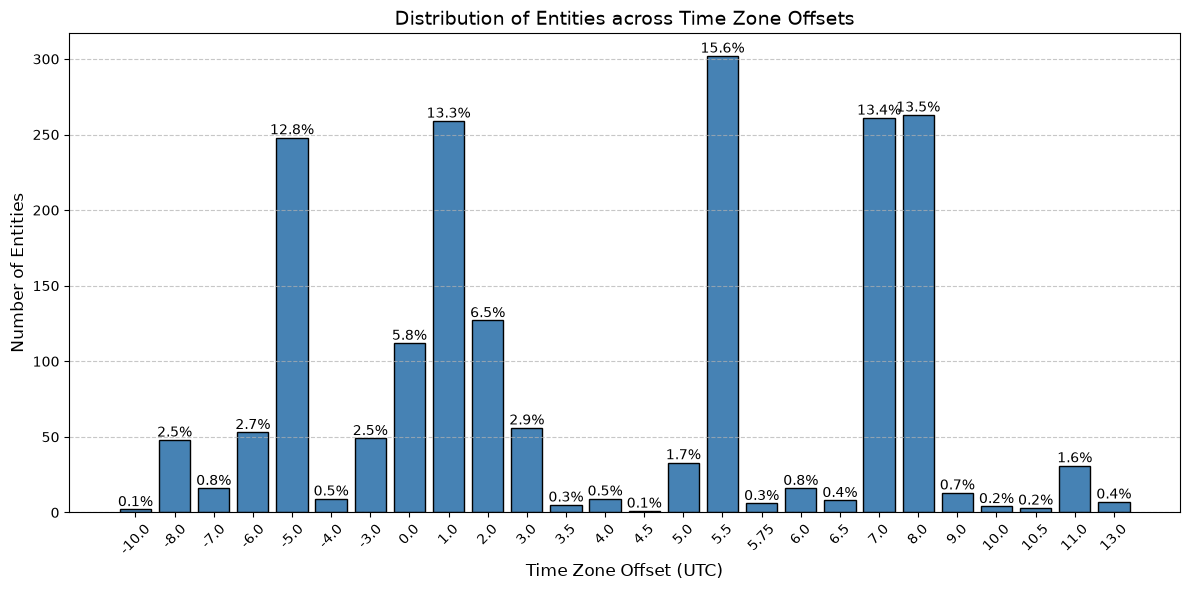

In [29]:
# 1. Count the occurrences of each offset 
offset_counts = table['offset'].value_counts().sort_index()

# Calculate the total number of entities to compute percentages
total_entities = len(table)

# 2. Set up the visualization using subplots for easier annotation control
fig, ax = plt.subplots(figsize=(12, 6))

# Create the bars and store them in a variable
bars = ax.bar(offset_counts.index.astype(str), offset_counts.values, color='steelblue', edgecolor='black')

# 3. Add the percentage labels on top of the columns
for bar in bars:
    count = bar.get_height()
    percentage = (count / total_entities) * 100
    
    # Place the text centered above each bar
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # X position: middle of the bar
        count,                              # Y position: top of the bar
        f'{percentage:.1f}%',               # Text: formatted to 1 decimal place
        ha='center',                        # Horizontally center the text
        va='bottom',                        # Vertically align to the bottom of the text bounding box
        fontsize=10
    )

# 4. Add formatting and labels tailored to the data
plt.title('Distribution of Entities across Time Zone Offsets', fontsize=14)
plt.xlabel('Time Zone Offset (UTC)', fontsize=12)
plt.ylabel('Number of Entities', fontsize=12)

# Rotate the labels slightly in case the offset names get crowded
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Render the graph
plt.tight_layout()
plt.show()

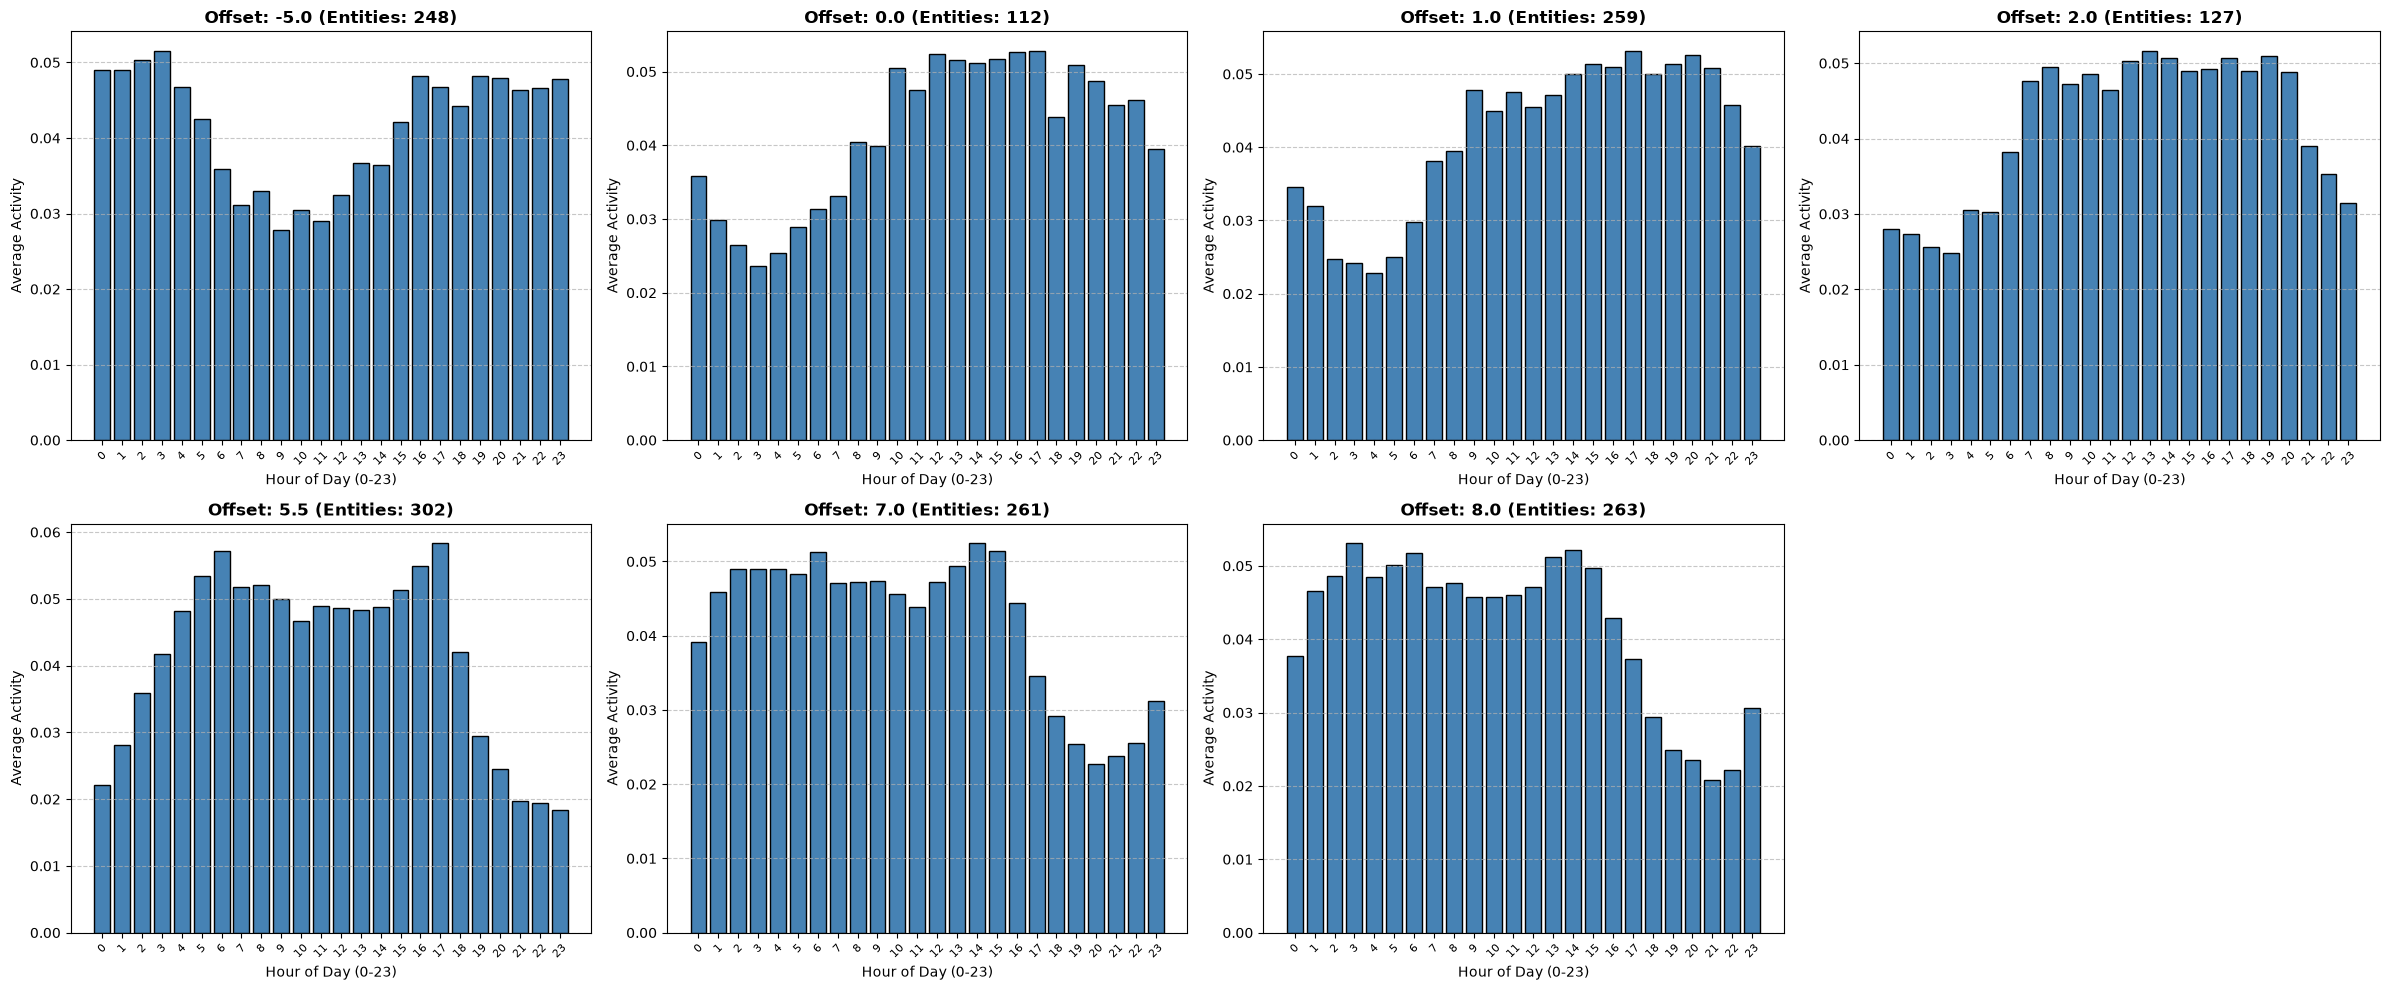

In [30]:
# 1. Find the top 7 largest offsets by entity count, then sort them by the offset value (smallest to largest)
top_7_offsets = table['offset'].value_counts().nlargest(7).sort_index()

# 2. Identify the hour columns (0 to 23)
activity_cols = [col for col in table.columns if str(col).isdigit() and 0 <= int(col) <= 23]
activity_cols = sorted(activity_cols, key=lambda x: int(x))

# 3. Create a single figure with a 2x4 grid (2 rows, 4 columns)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 10))
axes = axes.flatten() # Flatten the 2D array of axes for easier looping

# 4. Loop through the sorted top 7 offsets and plot their average activity
for i, (offset_val, count) in enumerate(top_7_offsets.items()):
    ax = axes[i]
    
    # Filter data for the current offset
    subset = table[table['offset'] == offset_val]
    
    # Calculate the AVERAGE (mean) across the 0-23 columns
    avg_activity = subset[activity_cols].mean()
    
    # Plot as a bar chart to show the distribution
    ax.bar(avg_activity.index.astype(str), avg_activity.values, color='steelblue', edgecolor='black')
    
    # Add title with the offset value and the exact number of entities
    ax.set_title(f'Offset: {offset_val} (Entities: {count})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Hour of Day (0-23)', fontsize=10)
    ax.set_ylabel('Average Activity', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Rotate x-axis labels to ensure they fit nicely in a 4-column layout
    ax.tick_params(axis='x', rotation=45, labelsize=8)

# 5. Hide the 8th (unused) subplot since we only need 7 graphs
axes[7].set_visible(False)

# 6. Adjust spacing and render
plt.tight_layout()
plt.show()

# Creating regions

In [31]:
#Mapping and grouping data by defined regions
region_mapping = {
    # America
    -8.0: 'America', -7.0: 'America', -6.0: 'America', -5.0: 'America', -4.0: 'America', -3.0: 'America',
    
    # Euro-Africa
    0.0: 'Euro_Africa', 1.0: 'Euro_Africa', 2.0: 'Euro_Africa', 3.0: 'Euro_Africa',
    
    # Central Asia / India / Middle East
    3.5: 'Central_South_Asia', 4.0: 'Central_South_Asia', 4.5: 'Central_South_Asia', 5.0: 'Central_South_Asia', 
    5.5: 'Central_South_Asia', 5.75: 'Central_South_Asia', 6.0: 'Central_South_Asia', 6.5: 'Central_South_Asia',
    
    # East Asia / Pacific
    7.0: 'East_Asia_Pac', 8.0: 'East_Asia_Pac', 9.0: 'East_Asia_Pac', 10.0: 'East_Asia_Pac', 10.5: 'East_Asia_Pac', 11.0: 'East_Asia_Pac', 
    12.0: 'East_Asia_Pac', 13.0: 'East_Asia_Pac', -10.0: 'East_Asia_Pac', -9.0: 'East_Asia_Pac'
}

table['region'] = table['offset'].map(region_mapping)

In [32]:
table.head()

,entity,offset,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,total,log_total,min_5h_activity,min_5h_activity_sin,min_5h_activity_cos,min_5h_activity_%,lifespan_days,0_weekday,1_weekday,2_weekday,3_weekday,4_weekday,5_weekday,6_weekday,7_weekday,8_weekday,9_weekday,10_weekday,11_weekday,12_weekday,13_weekday,14_weekday,15_weekday,16_weekday,17_weekday,18_weekday,19_weekday,20_weekday,21_weekday,22_weekday,23_weekday,0_weekend,1_weekend,2_weekend,3_weekend,4_weekend,5_weekend,6_weekend,7_weekend,8_weekend,9_weekend,10_weekend,11_weekend,12_weekend,13_weekend,14_weekend,15_weekend,16_weekend,17_weekend,18_weekend,19_weekend,20_weekend,21_weekend,22_weekend,23_weekend,total_weekday,total_weekend,region
0,Entity 100,7.0,0.020921,0.037657,0.025105,0.050209,0.050209,0.058577,0.033473,0.054393,0.050209,0.046025,0.046025,0.071130,0.037657,0.033473,0.054393,0.054393,0.062762,0.112971,0.037657,0.016736,0.012552,0.016736,0.004184,0.012552,215,5.370638,21,-0.707107,0.707107,0.062762,527.561829,0.022599,0.050847,0.028249,0.050847,0.067797,0.073446,0.039548,0.045198,0.033898,0.056497,0.050847,0.050847,0.028249,0.022599,0.056497,0.073446,0.084746,0.062147,0.033898,0.022599,0.011299,0.016949,0.005650,0.011299,0.023256,0.011628,0.023256,0.046512,0.011628,0.023256,0.023256,0.069767,0.081395,0.023256,0.034884,0.104651,0.058140,0.058140,0.046512,0.011628,0.011628,0.197674,0.046512,0.011628,0.023256,0.023256,0.011628,0.023256,153.0,62.0,East_Asia_Pac
1,Entity 1000,2.0,0.107143,0.107143,0.071429,0.035714,0.017857,0.035714,0.053571,0.017857,0.035714,0.035714,0.089286,0.035714,0.053571,0.053571,0.017857,0.017857,0.017857,0.035714,0.017857,0.035714,0.017857,0.035714,0.017857,0.035714,32,3.465736,16,-0.866025,-0.500000,0.107143,125.700324,0.100000,0.100000,0.080000,0.040000,0.020000,0.020000,0.040000,0.020000,0.040000,0.040000,0.080000,0.040000,0.060000,0.040000,0.020000,0.020000,0.020000,0.040000,0.020000,0.040000,0.020000,0.040000,0.020000,0.040000,0.066667,0.066667,0.033333,0.033333,0.033333,0.066667,0.066667,0.033333,0.033333,0.033333,0.066667,0.033333,0.033333,0.066667,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,26.0,6.0,Euro_Africa
2,Entity 1001,2.0,0.034483,0.034483,0.051724,0.051724,0.068966,0.068966,0.103448,0.172414,0.051724,0.034483,0.034483,0.034483,0.017241,0.051724,0.017241,0.017241,0.017241,0.034483,0.017241,0.017241,0.017241,0.017241,0.017241,0.017241,34,3.526361,20,-0.866025,0.500000,0.086207,1093.023981,0.035714,0.035714,0.035714,0.053571,0.071429,0.071429,0.107143,0.178571,0.053571,0.035714,0.035714,0.035714,0.017857,0.053571,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.038462,0.038462,0.076923,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,0.076923,0.038462,0.038462,0.038462,0.038462,0.038462,0.038462,32.0,2.0,Euro_Africa
3,Entity 1002,-5.0,0.053571,0.071429,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.017857,0.035714,0.035714,0.053571,0.071429,0.125000,0.035714,0.053571,0.017857,0.071429,0.053571,0.035714,0.107143,32,3.465736,4,0.866025,0.500000,0.089286,1229.220995,0.066667,0.066667,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.022222,0.044444,0.088889,0.133333,0.044444,0.066667,0.022222,0.066667,0.066667,0.022222,0.044444,0.028571,0.057143,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.057143,0.057143,0.057143,0.028571,0.057143,0.028571,0.028571,0.028571,0.057143,0.028571,0.057143,0.142857,21.0,11.0,America
5,Entity 1004,7.0,0.017241,0.017241,0.017241,0.051724,0.086207,0.068966,0.086207,0.051724,0.017241,0.034483,0.086207,0.017241,0.103448,0.051724,0.017241,0.017241,0.051724,0.034483,0.068966,0.017241,0.034483,0.017241,0.017241,0.017241,34,3.526361,23,-0.258819,0.965926,0.086207,431.026157,0.018868,0.018868,0.0

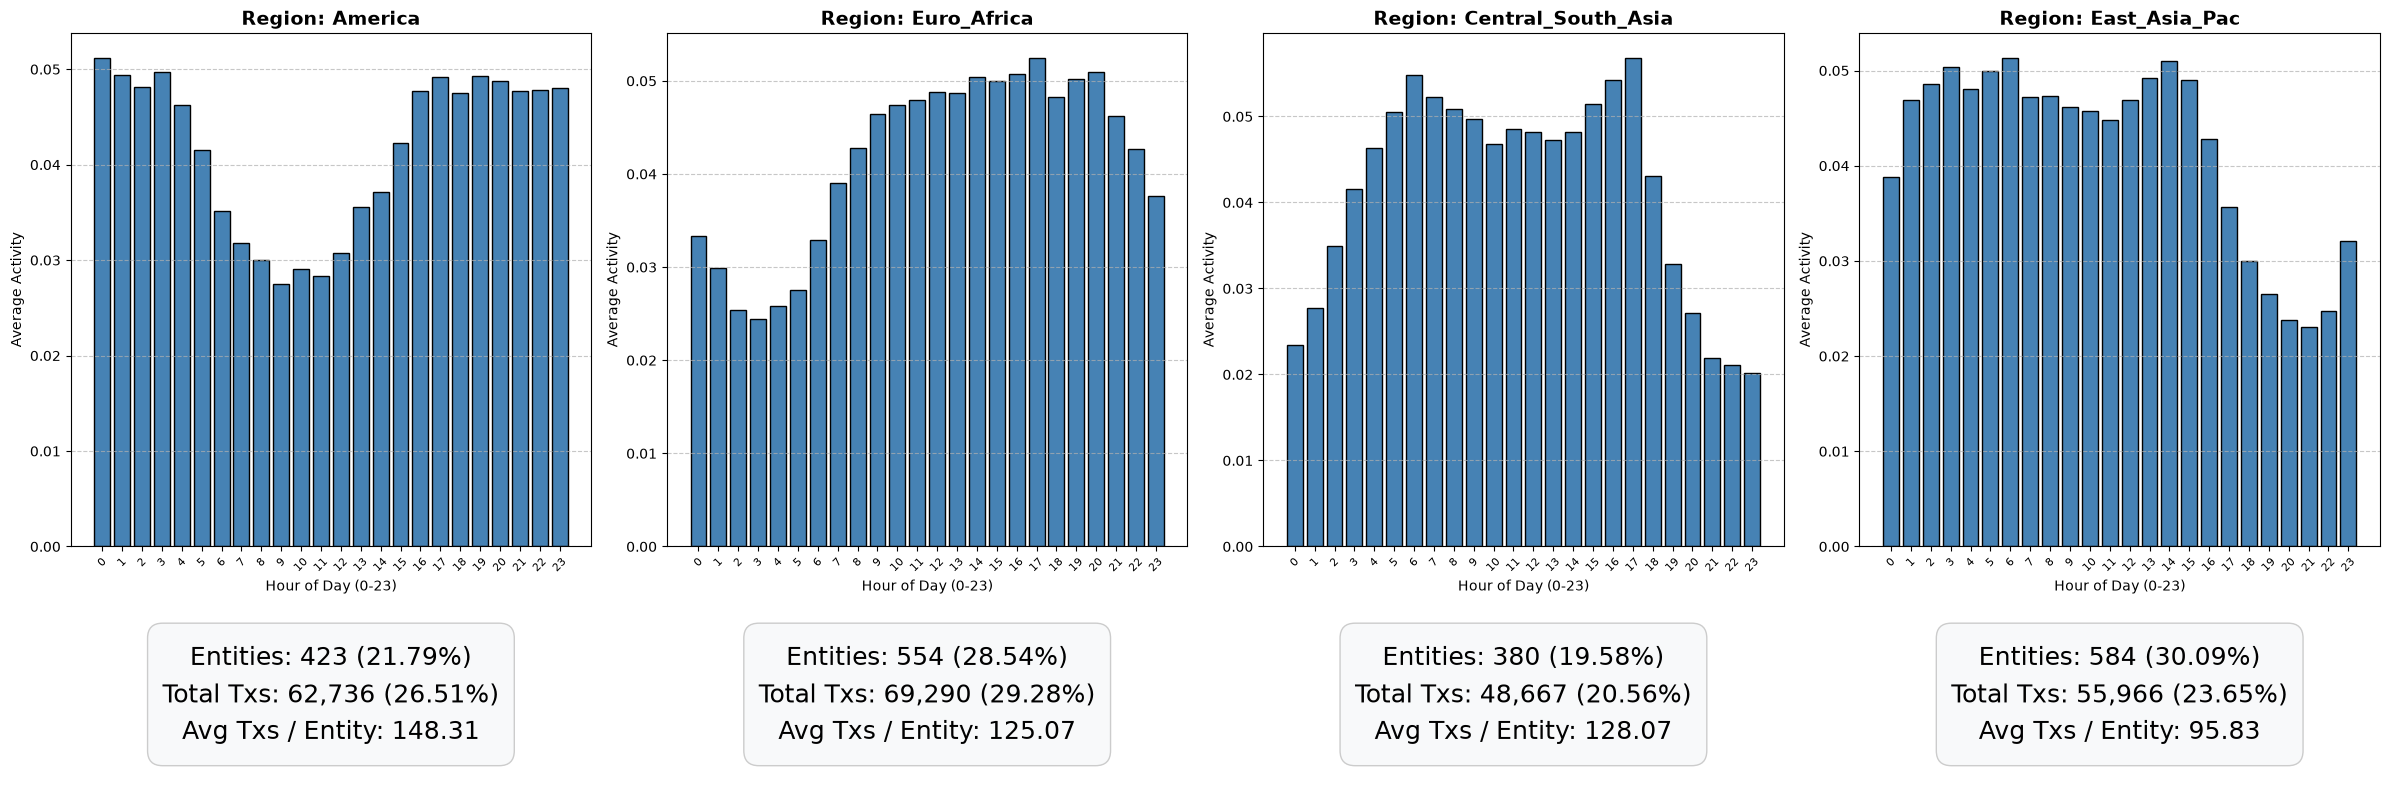

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. DATA PREPARATION & CALCULATIONS
# ---------------------------------------------------------

activity_cols = [col for col in table.columns if str(col).isdigit() and 0 <= int(col) <= 23]
activity_cols = sorted(activity_cols, key=lambda x: int(x))
total_entities_all = len(table)
total_txs_all = table['total'].sum()

summary_table = table.groupby('region').agg(
    number_of_entities=('entity', 'count'),
    number_of_txs=('total', 'sum')
).reset_index()

summary_table['avg_txs_per_entity'] = summary_table['number_of_txs'] / summary_table['number_of_entities']
summary_table['entity_percentage'] = (summary_table['number_of_entities'] / total_entities_all) * 100
summary_table['txs_percentage'] = (summary_table['number_of_txs'] / total_txs_all) * 100

summary_table = summary_table.round({'avg_txs_per_entity': 2, 'entity_percentage': 2, 'txs_percentage': 2})

# ---------------------------------------------------------
# 2. SPECIFY DESIRED REGION ORDER
# ---------------------------------------------------------

desired_order = ['America', 'Euro_Africa', 'Central_South_Asia', 'East_Asia_Pac']

# Filter to ensure only existing regions in the data are processed in order
regions_to_plot = [r for r in desired_order if r in table['region'].values]

# ---------------------------------------------------------
# 3. VISUALIZATION: HISTOGRAMS WITH STATS UNDERNEATH
# ---------------------------------------------------------

# Create 2 rows: Top row for Histograms, Bottom row for Region Stats
fig, axes = plt.subplots(
    nrows=2, 
    ncols=len(regions_to_plot), 
    figsize=(24, 8), 
    gridspec_kw={'height_ratios': [3, 1]}
)

for i, region in enumerate(regions_to_plot):
    ax_chart = axes[0, i]
    ax_stats = axes[1, i]
    
    # Filter data for current region
    subset = table[table['region'] == region]
    avg_activity = subset[activity_cols].mean()
    
    # Get summary statistics row for this region
    reg_stats = summary_table[summary_table['region'] == region].iloc[0]
    
    # --- TOP ROW: Histogram Plot ---
    ax_chart.bar(avg_activity.index.astype(str), avg_activity.values, color='steelblue', edgecolor='black')
    ax_chart.set_title(f'Region: {region}', fontsize=14, fontweight='bold')
    ax_chart.set_xlabel('Hour of Day (0-23)', fontsize=10)
    ax_chart.set_ylabel('Average Activity', fontsize=10)
    ax_chart.grid(axis='y', linestyle='--', alpha=0.7)
    ax_chart.tick_params(axis='x', rotation=45, labelsize=8)
    
    # --- BOTTOM ROW: Region Specific Stats ---
    ax_stats.axis('off')  # Hide axis ticks and box
    
    stats_text = (
        f"Entities: {int(reg_stats['number_of_entities']):,} ({reg_stats['entity_percentage']:.2f}%)\n"
        f"Total Txs: {int(reg_stats['number_of_txs']):,} ({reg_stats['txs_percentage']:.2f}%)\n"
        f"Avg Txs / Entity: {reg_stats['avg_txs_per_entity']:.2f}"
    )
    
    # Add formatted text box directly beneath the corresponding histogram
    ax_stats.text(
        0.5, 0.5, stats_text,
        transform=ax_stats.transAxes,
        fontsize=18,
        ha='center',
        va='center',
        linespacing=1.5,
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#f8f9fa', edgecolor='#cccccc', linewidth=1)
    )

plt.tight_layout()
plt.show()

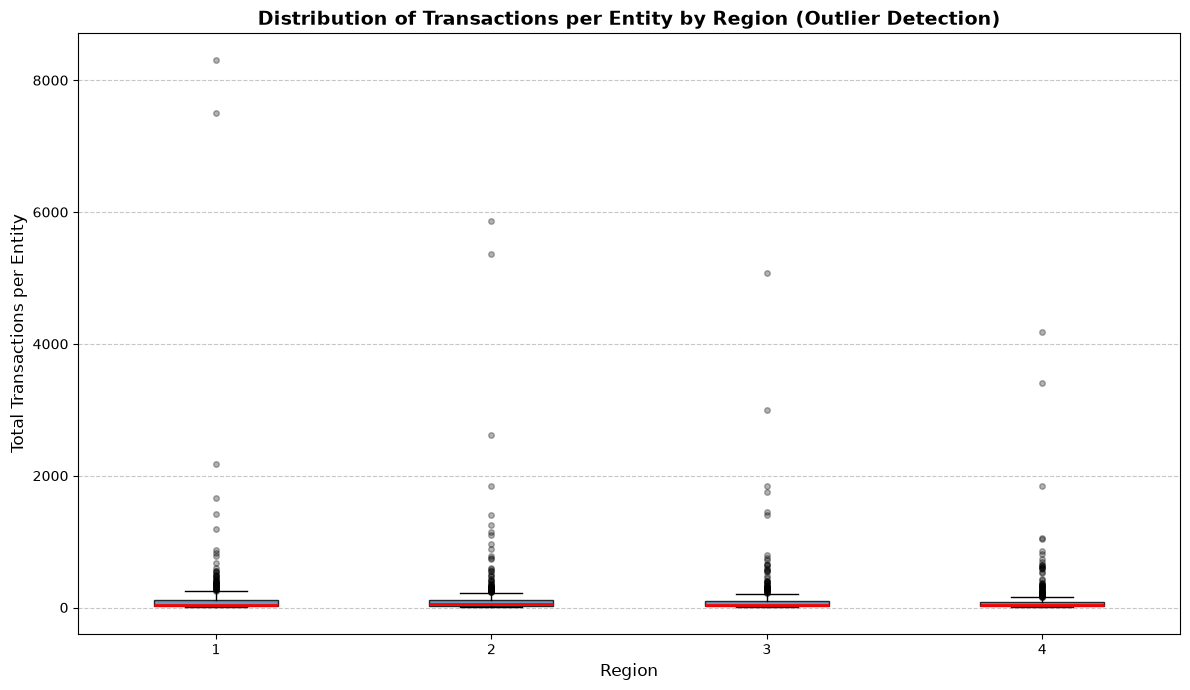

In [38]:
# Ensure we only try to plot regions that actually exist in the dataset
regions_to_plot = [r for r in desired_order if r in table['region'].values]

# Group the transaction data by region into a list of arrays for matplotlib
data_to_plot = [table[table['region'] == region]['total'] for region in regions_to_plot]

# Create the box plot figure
plt.figure(figsize=(12, 7))

# Plot the data
# - patch_artist=True allows us to fill the boxes with color
# - flierprops controls the appearance of the outlier markers (the dots)
plt.boxplot(
    data_to_plot, 
    label=regions_to_plot, 
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', color='black', alpha=0.8),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', color='black', markerfacecolor='black', alpha=0.3, markersize=4)
)

# Formatting and labels
plt.title('Distribution of Transactions per Entity by Region (Outlier Detection)', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Transactions per Entity', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# ---------------------------------------------------------
# OPTIONAL: LOG SCALE
# If extreme outliers make the main boxes unreadable, 
# uncomment the line below to view the data on a log scale:
# ---------------------------------------------------------
# plt.yscale('log')

plt.tight_layout()
plt.show()

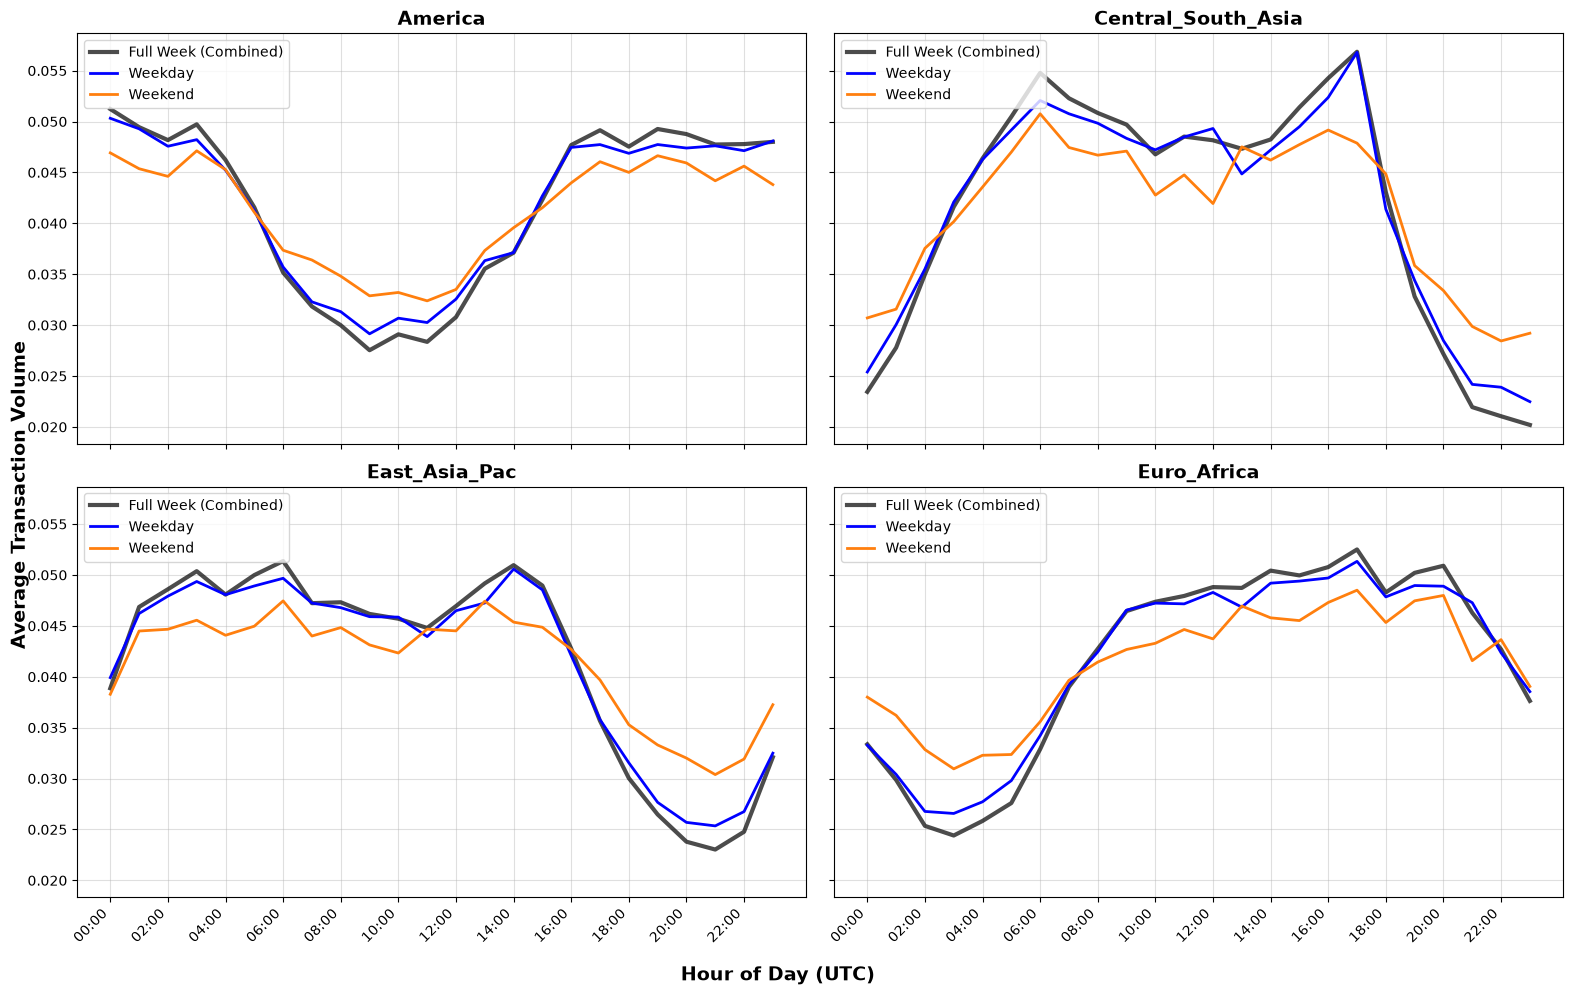

In [40]:
# 1. Group the data by region
table.columns = table.columns.astype(str)  # Ensure all column names are strings for consistency
region_means = table.groupby('region').mean(numeric_only=True)


# 2. Define column names
weekday_cols = [f"{i}_weekday" for i in range(24)]
weekend_cols = [f"{i}_weekend" for i in range(24)]
combined_cols = [f"{i}" for i in range(24)] 

# 3. Create a 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

regions = ["America", "Central_South_Asia", "East_Asia_Pac", "Euro_Africa"]
tick_positions = range(0, 24, 2)
tick_labels = [f"{h:02d}:00" for h in tick_positions]

for i, region in enumerate(regions):
    if region in region_means.index:
        # Extract the specific row of averages for this region
        weekday_data = region_means.loc[region, weekday_cols].values
        weekend_data = region_means.loc[region, weekend_cols].values
        combined_data = region_means.loc[region, combined_cols].values
          
        # Plot the Combined Full Week trend (Thick dark line)
        axes[i].plot(range(24), combined_data, label='Full Week (Combined)', color='black', linewidth=3, alpha=0.7)

        # Plot the separated Weekday and Weekend trends
        axes[i].plot(range(24), weekday_data, label='Weekday', color='blue', linewidth=2)
        axes[i].plot(range(24), weekend_data, label='Weekend', color='#ff7f0e', linewidth=2)
        
        # Formatting
        axes[i].set_title(f"{region}", fontsize=14, fontweight='bold')
        axes[i].set_xticks(tick_positions)
        axes[i].set_xticklabels(tick_labels, rotation=45, ha='right')
        axes[i].grid(True, alpha=0.4)
        axes[i].legend(loc="upper left", fontsize=10)



# 4. Add overarching labels and save
fig.supxlabel("Hour of Day (UTC)", fontsize=14, fontweight='bold')
fig.supylabel("Average Transaction Volume", fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()
plt.close()

In [41]:
table.to_csv("database_from_bitcointalk.csv")